**<h1 align="center">Results Analysis</h1>**

This notebook analyzes the results of the different approaches evaluated in the study, including the SBERT baseline, fixed hybrid methods, and learned rerankers. It compares their performance across retrieval metrics.

# Table of Contents
* [1. Imports & Setup](#chapter1)
* [2. Load Results](#chapter2)
* [3. Comparison Tables](#chapter3)
* [4. Checks](#chapter4)
* [5. Summary Comparison](#chapter5)

<a class="anchor" id="chapter1"></a>

# 1. Imports & Setup

</a>

In [1]:
import os
import pandas as pd
import numpy as np
import sys
import json
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Project root (assumes notebook is in /Notebook)
PROJECT_ROOT = Path("..").resolve()

# Allow imports from project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from Utils.thesis_utility import metrics_dict_to_series

/opt/anaconda3/envs/ResumeMatcherThesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
RESULTS_PATH = PROJECT_ROOT / "Results"

<a class="anchor" id="chapter2"></a>

# 2. Load Results

</a>

In [5]:
# Baseline for off the shelf and tuned models

with open(RESULTS_PATH / "Baseline" / "SBERT_off_shelf_val_metrics_01202026_1923.json", "r") as f:
    off_shelf_val = json.load(f)

with open(RESULTS_PATH / "Baseline" / "SBERT_off_shelf_test_metrics_01202026_1923.json", "r") as f:
    off_shelf_test = json.load(f)

with open(RESULTS_PATH / "Baseline" / "SBERT_tuned_val_metrics_01202026_1923.json", "r") as f:
    tuned_val = json.load(f)

with open(RESULTS_PATH / "Baseline" / "SBERT_tuned_test_metrics_01202026_1923.json", "r") as f:
    tuned_test = json.load(f)

In [6]:
# ESCO features for off the shelf and tuned models
with open(RESULTS_PATH / "Hybrid" / "ESCO_fixedhybrid_offshelf_val_01222026_1755.json", "r") as f:
    esco_off_shelf_val = json.load(f)

with open(RESULTS_PATH / "Hybrid" / "ESCO_fixedhybrid_offshelf_test_01222026_1755.json", "r") as f:
    esco_off_shelf_test = json.load(f)

with open(RESULTS_PATH / "Hybrid" / "ESCO_fixedhybrid_tuned_val_01222026_1755.json", "r") as f:
    esco_tuned_val = json.load(f)

with open(RESULTS_PATH / "Hybrid" / "ESCO_fixedhybrid_tuned_test_01222026_1755.json", "r") as f:
    esco_tuned_test = json.load(f)

In [7]:
# Tuned Results
with open(RESULTS_PATH / "Hybrid" / "ESCO_tunedhybrid_offshelf_val_01222026_1755.json", "r") as f:
    tuned_esco_offshelf_val = json.load(f)

with open(RESULTS_PATH / "Hybrid" / "ESCO_tunedhybrid_offshelf_test_01222026_1755.json", "r") as f:
    tuned_esco_offshelf_test = json.load(f)

In [8]:
tuning_val_results = pd.read_csv(RESULTS_PATH / "Hybrid" / "ESCO_tuning_offshelf_VAL_01222026_1755.csv")

In [9]:
# Rerankers
with open(RESULTS_PATH / "Rerankers" / "ESCO_logreg_reranker_offshelf_val_01222026_1755.json", "r") as f:
    esco_logreg_offshelf_val = json.load(f)

with open(RESULTS_PATH / "Rerankers" / "ESCO_logreg_reranker_offshelf_test_01222026_1755.json", "r") as f:
    esco_logreg_offshelf_test = json.load(f)

with open(RESULTS_PATH / "Rerankers" / "ESCO_xgb_reranker_offshelf_val_02012026_1427.json", "r") as f:
    esco_xgb_offshelf_val = json.load(f)

with open(RESULTS_PATH / "Rerankers" / "ESCO_xgb_reranker_offshelf_test_02012026_1427.json", "r") as f:
    esco_xgb_offshelf_test = json.load(f)

<a class="anchor" id="chapter3"></a>

# 3. Comparison Tables
</a>

In [10]:
METRICS_TO_KEEP = ["recall@1", "recall@5", "recall@10", "recall@20", "mrr@10", "ndcg@10"]

In [44]:
val_table = pd.DataFrame({
    "SBERT off-the-shelf": metrics_dict_to_series(off_shelf_val),
    "SBERT fine-tuned": metrics_dict_to_series(tuned_val),
    "SBERT off-the-shelf + ESCO": metrics_dict_to_series(esco_off_shelf_val),
    "SBERT fine-tuned + ESCO": metrics_dict_to_series(esco_tuned_val),
    "SBERT off-the-shelf + ESCO (tuned)": metrics_dict_to_series(tuned_esco_offshelf_val),
    "Reranker (logreg)": metrics_dict_to_series(esco_logreg_offshelf_val),
    "Reranker (xgb)": metrics_dict_to_series(esco_xgb_offshelf_val),
})
val_table = val_table.loc[METRICS_TO_KEEP]
val_table

,SBERT off-the-shelf,SBERT fine-tuned,SBERT off-the-shelf + ESCO,SBERT fine-tuned + ESCO,SBERT off-the-shelf + ESCO (tuned),Reranker (logreg),Reranker (xgb)
recall@1,0.023359,0.020861,0.030750,0.029280,0.029190,0.031168,0.052594
recall@5,0.075230,0.071636,0.100555,0.095379,0.106883,0.109426,0.140300
recall@10,0.109776,0.108307,0.133508,0.130977,0.139984,0.143057,0.175355
recall@20,0.155579,0.156743,0.173027,0.175061,0.176451,0.179898,0.207687
mrr@10,0.045793,0.043075,0.060350,0.057675,0.062675,0.064334,0.089117
ndcg@10,0.060749,0.058274,0.077678,0.074964,0.081096,0.083063,0.109671


In [51]:
test_table = pd.DataFrame({
    "SBERT off-the-shelf": metrics_dict_to_series(off_shelf_test),
    "SBERT fine-tuned": metrics_dict_to_series(tuned_test),
    "SBERT off-the-shelf + ESCO": metrics_dict_to_series(esco_off_shelf_test),
    "SBERT fine-tuned + ESCO": metrics_dict_to_series(esco_tuned_test),
    "SBERT off-the-shelf + ESCO (tuned)": metrics_dict_to_series(tuned_esco_offshelf_test),
    "Reranker (logreg)": metrics_dict_to_series(esco_logreg_offshelf_test),
    "Reranker (xgb)": metrics_dict_to_series(esco_xgb_offshelf_test),
})

test_table = test_table.loc[METRICS_TO_KEEP]
test_table

,SBERT off-the-shelf,SBERT fine-tuned,SBERT off-the-shelf + ESCO,SBERT fine-tuned + ESCO,SBERT off-the-shelf + ESCO (tuned),Reranker (logreg),Reranker (xgb)
recall@1,0.023589,0.021220,0.030741,0.030019,0.029173,0.031204,0.049795
recall@5,0.075516,0.072459,0.100064,0.097086,0.107126,0.108119,0.136322
recall@10,0.108514,0.109574,0.132486,0.131539,0.139086,0.142166,0.171779
recall@20,0.155083,0.157959,0.171497,0.175592,0.174870,0.178785,0.203987
mrr@10,0.045936,0.043642,0.060181,0.058531,0.062306,0.063762,0.085541
ndcg@10,0.060595,0.059005,0.077317,0.075774,0.080599,0.082393,0.106054


<a class="anchor" id="chapter4"></a>

# 4. Checks
</a>

In [52]:
# Check that ranking metrics increase monotonically with K
def check_monotonicity(table, metric_prefix="recall"):
    problems = []

    # Iterate over each model (column)
    for model in table.columns:
        values = []
        Ks = []

        # Extract metric values
        for idx in table.index:
            if idx.startswith(metric_prefix):
                K = int(idx.split("@")[1])
                Ks.append(K)
                values.append(table.loc[idx, model])

        # Sort metrics by increasing K
        Ks, values = zip(*sorted(zip(Ks, values)))

        # Check that values do not decrease as K increases
        for i in range(1, len(values)):
            if values[i] + 1e-9 < values[i-1]:
                problems.append((model, metric_prefix, Ks[i-1], Ks[i], values[i-1], values[i]))

    return problems

In [53]:
print("Validation recall monotonicity issues:")
print(check_monotonicity(val_table, "recall"))

print("\nTest recall monotonicity issues:")
print(check_monotonicity(test_table, "recall"))

Validation recall monotonicity issues:
[]

Test recall monotonicity issues:
[]


This test is to ensure that ranking metrics behave as expected: performance should not decrease as K increases. Here, all models produce consistent and valid rankings.

<a class="anchor" id="chapter5"></a>

# 5. Summary Comparison
</a>

In [54]:
# Rank models based on a chosen metric (higher is better)
val_ranks = val_table.loc["recall@10"].rank(ascending=False)
test_ranks = test_table.loc["recall@10"].rank(ascending=False)

val_ranks, test_ranks

(SBERT off-the-shelf                   6.0
 SBERT fine-tuned                      7.0
 SBERT off-the-shelf + ESCO            4.0
 SBERT fine-tuned + ESCO               5.0
 SBERT off-the-shelf + ESCO (tuned)    3.0
 Reranker (logreg)                     2.0
 Reranker (xgb)                        1.0
 Name: recall@10, dtype: float64,
 SBERT off-the-shelf                   7.0
 SBERT fine-tuned                      6.0
 SBERT off-the-shelf + ESCO            4.0
 SBERT fine-tuned + ESCO               5.0
 SBERT off-the-shelf + ESCO (tuned)    3.0
 Reranker (logreg)                     2.0
 Reranker (xgb)                        1.0
 Name: recall@10, dtype: float64)

In [55]:
# Compute absolute performance differences between models (Δ)
for metric in ["recall@5", "recall@10", "ndcg@10", "mrr@10"]:
    val_delta = (
        val_table.loc[metric, "SBERT off-the-shelf + ESCO (tuned)"]
        - val_table.loc[metric, "SBERT off-the-shelf"]
    )
    test_delta = (
        test_table.loc[metric, "SBERT off-the-shelf + ESCO (tuned)"]
        - test_table.loc[metric, "SBERT off-the-shelf"]
    )

    print(metric, "VAL Δ:", val_delta, "TEST Δ:", test_delta)

recall@5 VAL Δ: 0.031653651866333676 TEST Δ: 0.03160994099928928
recall@10 VAL Δ: 0.030207144390828236 TEST Δ: 0.030572069988605982
ndcg@10 VAL Δ: 0.020346751678584074 TEST Δ: 0.020004455115158325
mrr@10 VAL Δ: 0.016882306418858732 TEST Δ: 0.01636979186531847


In [56]:
# Compute relative (%) improvements for key comparisons
metric = "recall@10"

def pct_gain(base, new):
    return 100.0 * (new - base) / max(base, 1e-9)

print(
    "ESCO gain over SBERT off shelf (test):",
    pct_gain(
        test_table.loc[metric, "SBERT off-the-shelf"],
        test_table.loc[metric, "SBERT off-the-shelf + ESCO"],
    ),
    "%"
)

print(
    "ESCO tuning gain over SBERT off shelf (test):",
    pct_gain(
        test_table.loc[metric, "SBERT off-the-shelf"],
        test_table.loc[metric, "SBERT off-the-shelf + ESCO (tuned)"],
    ),
    "%"
)

print(
    "ESCO gain over SBERT tuned (test):",
    pct_gain(
        test_table.loc[metric, "SBERT fine-tuned"],
        test_table.loc[metric, "SBERT fine-tuned + ESCO"],
    ),
    "%"
)

print(
    "Reranker (logreg) over SBERT off shelf (test):",
    pct_gain(
        test_table.loc[metric, "SBERT off-the-shelf"],
        test_table.loc[metric, "Reranker (logreg)"],
    ),
    "%"
)

print(
    "Reranker (xgb) over SBERT off shelf (test):",
    pct_gain(
        test_table.loc[metric, "SBERT off-the-shelf"],
        test_table.loc[metric, "Reranker (xgb)"],
    ),
    "%"
)

ESCO gain over SBERT off shelf (test): 22.091693523235268 %
ESCO tuning gain over SBERT off shelf (test): 28.17340679904356 %
ESCO gain over SBERT tuned (test): 20.045300113250285 %
Reranker (logreg) over SBERT off shelf (test): 31.01153966108742 %
Reranker (xgb) over SBERT off shelf (test): 58.30127871920156 %


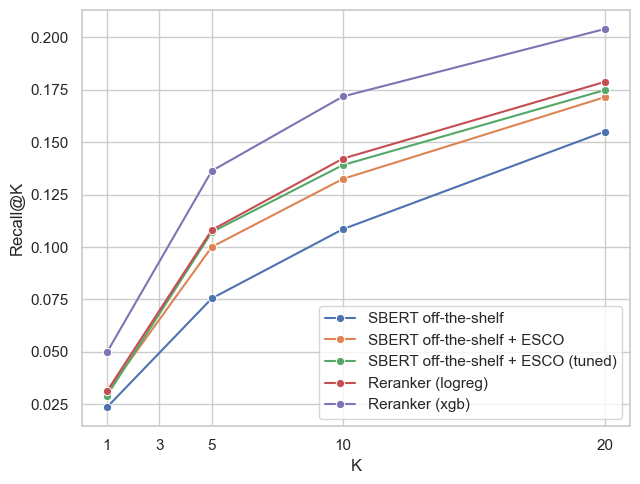

In [65]:
# Define systems and K values for plotting Recall@K curves
systems = [
    "SBERT off-the-shelf",
    "SBERT off-the-shelf + ESCO",
    "SBERT off-the-shelf + ESCO (tuned)",
    #"SBERT fine-tuned",
    #"SBERT fine-tuned + ESCO",
    "Reranker (logreg)",
    "Reranker (xgb)",
]

K_list = [1, 3, 5, 10, 20]

# Build dataframe for visualization
plot_rows = []
for sys in systems:
    for K in K_list:
        key = f"recall@{K}"
        if key in test_table.index:
            plot_rows.append({
                "System": sys,
                "K": K,
                "Recall": float(test_table.loc[key, sys])
            })

plot_df = pd.DataFrame(plot_rows)

# Plot Recall@K curves for all systems
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))

ax = sns.lineplot(
    data=plot_df,
    x="K",
    y="Recall",
    hue="System",
    marker="o"
)

plt.xticks(K_list)
plt.xlabel("K")
plt.ylabel("Recall@K")
plt.legend(title="", loc="lower right")
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

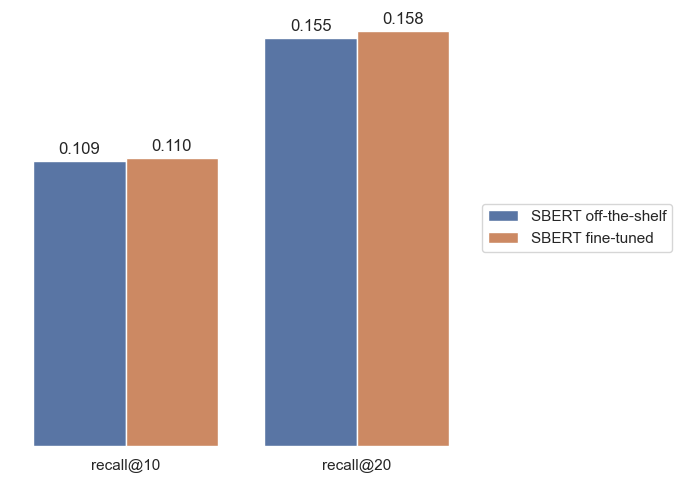

In [59]:
bar_df = (
    test_table.loc[["recall@10", "recall@20"], ["SBERT off-the-shelf", "SBERT fine-tuned"]]
    .reset_index()
    .melt(id_vars="index", var_name="Model", value_name="Recall")
    .rename(columns={"index": "Metric"})
)

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=bar_df, x="Metric", y="Recall", hue="Model")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

ax.grid(False)
ax.set_ylabel("")
ax.set_yticks([])
ax.set_xlabel("")


sns.despine(left=True, bottom=True)
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

# Move legend outside 
ax.legend(title="", bbox_to_anchor=(1.02, 0.5), loc="center left", borderaxespad=0)

#plt.title("Recall@10 and Recall@20 (Test Set): Off-the-shelf vs Fine-tuned SBERT")

plt.tight_layout()
plt.show()